# Analyse ventes + météo – Coffee shop Avignon

## Objectif du notebook

Ce notebook explore la relation entre les ventes journalières du coffee shop et les conditions météo à Avignon (température, précipitations, vent, etc.).

Il s’appuie sur le fichier fusionné `coffee_shop_avignon_ventes_meteo_2024_2025.csv` produit dans le notebook précédent, et prépare le terrain pour la phase de modélisation prédictive.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")

# Chemin vers le CSV fusionné exporté dans le notebook 1
merged_df = pd.read_csv(
    "Analyse_ventes_coffee_shop_Avignon_EDA/coffee_shop_avignon_ventes_meteo_2024_2025.csv",
    parse_dates=["date"]
)

merged_df.head()

,date,sales_total,transactions,average_basket,day_of_week,is_weekend,month,year,temp_max,temp_min,precipitation_sum,weather_code,wind_speed_max
0,2024-01-01,399.87,57,7.02,Monday,False,1,2024,12.3,3.3,0.0,3,17.1
1,2024-01-02,374.55,49,7.64,Tuesday,False,1,2024,10.1,0.9,0.8,53,10.0
2,2024-01-03,406.07,52,7.81,Wednesday,False,1,2024,11.6,4.0,0.0,3,14.2
3,2024-01-04,441.17,54,8.17,Thursday,False,1,2024,12.1,3.1,0.0,3,12.1
4,2024-01-05,370.96,54,6.87,Friday,False,1,2024,10.2,7.4,11.6,63,29.3


In [5]:
merged_df.info()
merged_df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               731 non-null    datetime64[ns]
 1   sales_total        731 non-null    float64       
 2   transactions       731 non-null    int64         
 3   average_basket     731 non-null    float64       
 4   day_of_week        731 non-null    object        
 5   is_weekend         731 non-null    bool          
 6   month              731 non-null    int64         
 7   year               731 non-null    int64         
 8   temp_max           731 non-null    float64       
 9   temp_min           731 non-null    float64       
 10  precipitation_sum  731 non-null    float64       
 11  weather_code       731 non-null    int64         
 12  wind_speed_max     731 non-null    float64       
dtypes: bool(1), datetime64[ns](1), float64(6), int64(4), object(1)
me

,count,mean,min,25%,50%,75%,max,std
date,731,2024-12-31 00:00:00,2024-01-01 00:00:00,2024-07-01 12:00:00,2024-12-31 00:00:00,2025-07-01 12:00:00,2025-12-31 00:00:00,NaN
sales_total,731.0,441.625294,271.88,399.26,439.28,483.375,671.29,58.315039
transactions,731.0,59.082079,36.0,52.0,58.0,65.0,86.0,8.944814
average_basket,731.0,7.518016,6.46,6.99,7.56,8.02,8.55,0.587839
month,731.0,6.519836,1.0,4.0,7.0,10.0,12.0,3.451913
year,731.0,2024.499316,2024.0,2024.0,2024.0,2025.0,2025.0,0.500342
temp_max,731.0,20.19357,2.9,13.9,19.4,25.9,38.7,8.003937
temp_min,731.0,11.225718,-4.1,6.4,10.9,16.25,26.1,6.32855
precipitation_sum,731.0,2.888919,0.0,0.0,0.0,1.05,72.2,7.755442
weather_code,731.0,24.042408,0.0,3.0,3.0,53.0,71.0,27.038929


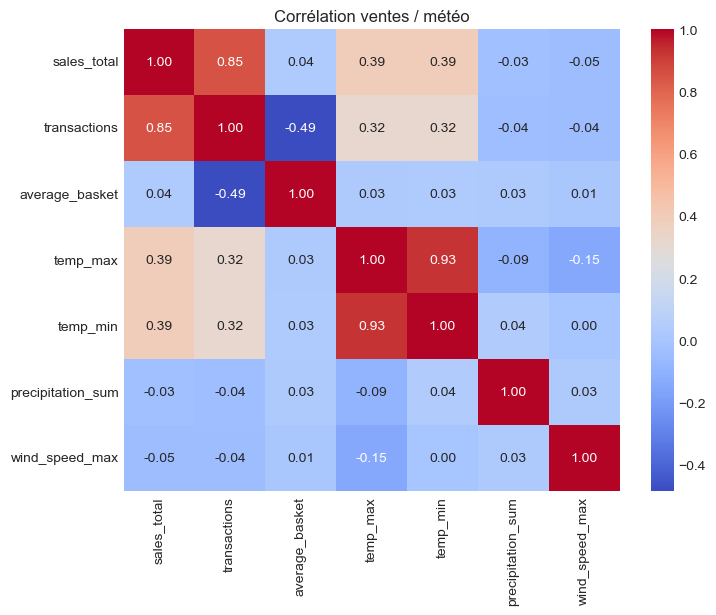

In [7]:
# Matrice de corrélation
num_cols = ["sales_total", "transactions", "average_basket",
            "temp_max", "temp_min", "precipitation_sum", "wind_speed_max"]

plt.figure(figsize=(8, 6))
corr = merged_df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Corrélation ventes / météo")
plt.show()

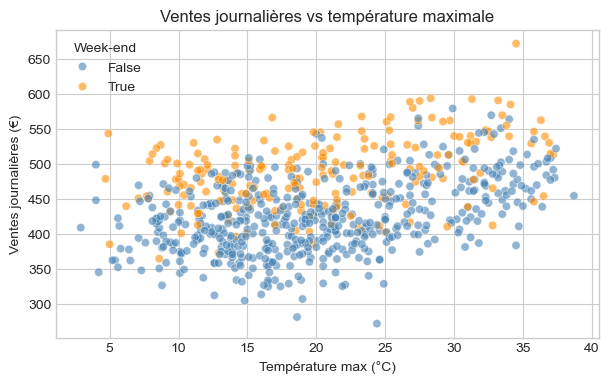

In [9]:
#Ventes vs température maximale
plt.figure(figsize=(7, 4))
sns.scatterplot(
    data=merged_df,
    x="temp_max",
    y="sales_total",
    hue="is_weekend",
    palette={False: "steelblue", True: "darkorange"},
    alpha=0.6
)
plt.title("Ventes journalières vs température maximale")
plt.xlabel("Température max (°C)")
plt.ylabel("Ventes journalières (€)")
plt.legend(title="Week-end")
plt.show()

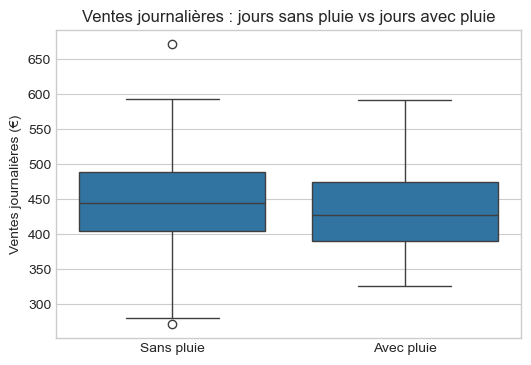

In [11]:
#Ventes selon présence de pluie
# Pluie vs pas de pluie
merged_df["is_rain"] = (merged_df["precipitation_sum"] > 0).astype(int)

plt.figure(figsize=(6, 4))
sns.boxplot(
    data=merged_df,
    x="is_rain",
    y="sales_total"
)
plt.xticks([0, 1], ["Sans pluie", "Avec pluie"])
plt.title("Ventes journalières : jours sans pluie vs jours avec pluie")
plt.xlabel("")
plt.ylabel("Ventes journalières (€)")
plt.show()

## Premiers constats météo-business

Les corrélations numériques donnent une première idée du lien entre météo et performance du coffee shop.  
On peut notamment observer si les ventes ont tendance à augmenter ou diminuer avec la température, la pluie ou le vent.

Le nuage de points ventes vs température maximale permet de visualiser la forme de la relation et de distinguer le comportement semaine vs week-end.  
Enfin, la comparaison des ventes entre jours pluvieux et non pluvieux donne un premier aperçu de l’impact de la pluie sur le chiffre d’affaires.

Ces observations serviront de base pour le feature engineering météo (création de classes de température, catégories de pluie, indicateurs combinant week-end et météo) avant de passer à la phase de modélisation.

## Analyse météo-business

### Corrélations ventes / météo

La matrice de corrélation met en évidence plusieurs points importants :

- Les ventes totales (`sales_total`) sont fortement corrélées au nombre de transactions (`transactions`), ce qui confirme que c’est principalement le volume de clients qui pilote le chiffre d’affaires.
- Le panier moyen (`average_basket`) est très peu corrélé aux ventes, ce qui suggère qu’il varie relativement peu et que l’effet principal se situe sur le trafic.
- Les ventes présentent une corrélation positive modérée avec la température (`temp_max`, `temp_min`), ce qui laisse penser que les journées plus douces/chaudes sont en moyenne plus favorables à l’activité du coffee shop.
- La corrélation entre ventes et précipitations ou vent est très faible, ce qui indique que leur impact global sur la période reste limité.

### Ventes vs température maximale

Le nuage de points “ventes journalières vs température maximale”, coloré selon le week-end, apporte des nuances complémentaires :

- On observe une tendance générale à la hausse : lorsque la température maximale augmente, les ventes ont tendance à être légèrement plus élevées.
- Les points correspondant au week-end se situent globalement au-dessus des points de semaine pour une même température, ce qui confirme le poids du facteur calendrier.
- Les meilleures journées de ventes se concentrent souvent sur des températures agréables, combinées à des jours de week-end.

Ainsi, la température semble jouer un rôle de facteur d’amplification : un week-end avec une météo favorable génère plus facilement de bonnes journées de ventes.

### Ventes selon la pluie

La comparaison des ventes entre jours avec et sans pluie montre :

- Des médianes de ventes relativement proches entre les deux groupes.
- Une dispersion des ventes présente dans les deux cas, avec des journées fortes même en l’absence de pluie.
- Aucun effet massif et isolé de la pluie sur le chiffre d’affaires sur l’ensemble de la période.

Cela suggère que la pluie, prise seule, n’est pas un facteur explicatif majeur des variations de ventes.
Son impact éventuel devra plutôt être analysé en interaction avec d’autres dimensions (week-end, saison, température).

### Synthèse intermédiaire

À ce stade, la météo semble influencer l’activité principalement via la température, tandis que la variable calendrier (semaine vs week-end) reste le facteur dominant.
Ces constats orientent le feature engineering à venir :
- création de classes de température (froid / doux / chaud),
- indicateurs simples de pluie,
- et variables combinant week-end et conditions météo.

In [17]:
# Température moyenne quotidienne
merged_df["temp_mean_day"] = (merged_df["temp_max"] + merged_df["temp_min"]) / 2

# Buckets de température
merged_df["temp_bucket"] = pd.cut(
    merged_df["temp_mean_day"],
    bins=[-100, 10, 20, 27, 100],
    labels=["cold", "mild", "warm", "hot"]
)

merged_df["temp_bucket"].value_counts()

temp_bucket
mild    346
cold    174
warm    164
hot      47
Name: count, dtype: int64

In [19]:
merged_df["rain_category"] = pd.cut(
    merged_df["precipitation_sum"],
    bins=[-0.1, 0, 2, 10, 1000],
    labels=["no_rain", "light", "moderate", "heavy"]
)

merged_df["rain_category"].value_counts()

rain_category
no_rain     441
light       137
moderate     82
heavy        71
Name: count, dtype: int64

In [21]:
merged_df["is_rain"] = (merged_df["precipitation_sum"] > 0).astype(int)

In [23]:
def classify_weather_row(row):
    # météo "favorable" : doux/chaud, sans pluie forte
    if (row["temp_mean_day"] >= 15) and (row["temp_mean_day"] <= 28) and (row["rain_category"] in ["no_rain", "light"]):
        return "favorable"
    # météo "défavorable" : froid ou pluie modérée/forte
    if (row["temp_mean_day"] < 10) or (row["rain_category"] in ["moderate", "heavy"]):
        return "unfavorable"
    # sinon intermédiaire
    return "average"

merged_df["weather_feel"] = merged_df.apply(classify_weather_row, axis=1)
merged_df["weather_feel"].value_counts()

weather_feel
unfavorable    299
favorable      270
average        162
Name: count, dtype: int64

In [25]:
merged_df["weekend_good_weather"] = (
    (merged_df["is_weekend"]) &
    (merged_df["weather_feel"] == "favorable")
).astype(int)

merged_df["weekend_good_weather"].value_counts()

weekend_good_weather
0    657
1     74
Name: count, dtype: int64

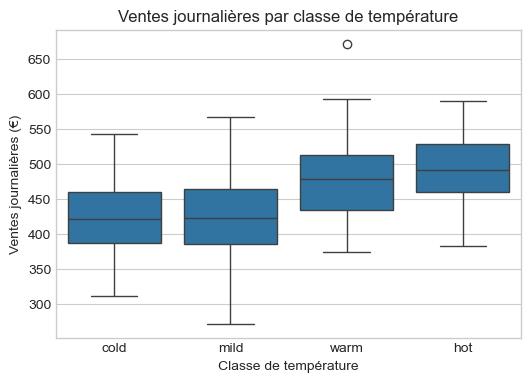

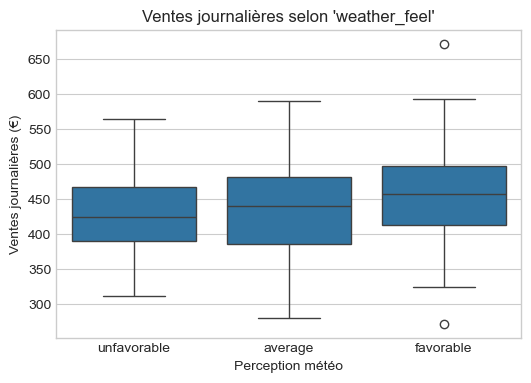

In [27]:
# Ventes selon temp_bucket
plt.figure(figsize=(6, 4))
sns.boxplot(data=merged_df, x="temp_bucket", y="sales_total")
plt.title("Ventes journalières par classe de température")
plt.xlabel("Classe de température")
plt.ylabel("Ventes journalières (€)")
plt.show()

# Ventes selon weather_feel
plt.figure(figsize=(6, 4))
sns.boxplot(data=merged_df, x="weather_feel", y="sales_total")
plt.title("Ventes journalières selon 'weather_feel'")
plt.xlabel("Perception météo")
plt.ylabel("Ventes journalières (€)")
plt.show()

## Feature engineering météo

Afin de rendre les variables météo plus interprétables et exploitables dans un modèle, plusieurs variables dérivées ont été créées :

- `temp_mean_day` : moyenne de la température max et min sur la journée.
- `temp_bucket` : classes de température (cold / mild / warm / hot) définies à partir de seuils adaptés au climat local.
- `rain_category` : intensité de la pluie (no_rain / light / moderate / heavy), construite à partir du cumul journalier.
- `is_rain` : indicateur binaire de présence de pluie.
- `weather_feel` : perception globale de la météo (favorable / average / unfavorable) combinant température et pluie.
- `weekend_good_weather` : indicateur des jours de week-end avec météo favorable.

Ces variables permettent de relier plus directement la météo à des situations métier (week-end ensoleillé vs week-end pluvieux, journée froide, épisode de forte pluie, etc.) et seront utilisées comme variables explicatives dans le modèle prédictif.

In [32]:
# ============================================================
# Export du dataset enrichi (ventes + météo + features)
# ============================================================

import os

output_folder = "Analyse_ventes_coffee_shop_Avignon_EDA"
os.makedirs(output_folder, exist_ok=True)

merged_enriched_path = os.path.join(
    output_folder,
    "coffee_shop_avignon_ventes_meteo_features_2024_2025.csv"
)

merged_df.to_csv(merged_enriched_path, index=False)
print(f"Fichier ventes + météo + features exporté : {merged_enriched_path}")

Fichier ventes + météo + features exporté : Analyse_ventes_coffee_shop_Avignon_EDA\coffee_shop_avignon_ventes_meteo_features_2024_2025.csv
